<a href="https://colab.research.google.com/github/JihoonJung2/undergrad-research-practicum/blob/main/day5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import OxfordIIITPet
from torch.utils.data import DataLoader, Subset
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# 이미지, 마스크 각각 별도 transform 필요 (마스크는 보간 없이 그대로 리사이즈해야 함)
img_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
mask_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.NEAREST),  # 마스크는 픽셀값이 클래스 번호라 보간하면 안 됨
    transforms.PILToTensor(),
])

def joint_transform(img, mask):
    img = img_transform(img)
    mask = mask_transform(mask).squeeze(0).long() - 1   # 원본 라벨이 1,2,3 → 0,1,2로 맞춤
    return img, mask

class SegDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset):
        self.base_dataset = base_dataset
    def __len__(self):
        return len(self.base_dataset)
    def __getitem__(self, idx):
        img, mask = self.base_dataset[idx]
        return joint_transform(img, mask)

# target_types='segmentation'이면 마스크(픽셀별 클래스: 1=pet, 2=background, 3=border)까지 같이 받아옴
full_trainset = OxfordIIITPet(root='./data', split='trainval', target_types='segmentation', download=True)
full_testset = OxfordIIITPet(root='./data', split='test', target_types='segmentation', download=True)

trainset = SegDataset(Subset(full_trainset, np.random.choice(len(full_trainset), 500, replace=False)))
testset = SegDataset(Subset(full_testset, np.random.choice(len(full_testset), 100, replace=False)))

trainloader = DataLoader(trainset, batch_size=8, shuffle=True, num_workers=2)
testloader = DataLoader(testset, batch_size=8, shuffle=False, num_workers=2)

NUM_CLASSES = 3  # pet, background, border

cuda


100%|██████████| 792M/792M [00:31<00:00, 25.5MB/s]
100%|██████████| 19.2M/19.2M [00:02<00:00, 8.74MB/s]


In [2]:
class DoubleConv(nn.Module):
    """Conv-BN-ReLU를 2번 반복하는 기본 블록 (U-Net 어디서든 반복 사용)"""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        # Encoder: 압축하면서 특징 추출 (일반 CNN과 동일한 방향)
        self.enc1 = DoubleConv(3, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)

        # Bottleneck: 가장 압축된 지점
        self.bottleneck = DoubleConv(256, 512)

        # Decoder: 다시 키우면서 원본 해상도로 복원
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)   # 크기 2배로 키움
        self.dec3 = DoubleConv(512, 256)   # 512 = up3 출력(256) + skip connection(256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(256, 128)   # 256 = up2 출력(128) + skip connection(128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(128, 64)    # 128 = up1 출력(64) + skip connection(64)

        self.out_conv = nn.Conv2d(64, num_classes, kernel_size=1)   # 최종: 픽셀별 클래스 점수

    def forward(self, x):
        # Encoder — 압축하면서 각 단계 결과를 저장해둠 (나중에 skip connection용)
        e1 = self.enc1(x)              # 128x128, 64채널
        e2 = self.enc2(self.pool(e1))  # 64x64, 128채널
        e3 = self.enc3(self.pool(e2))  # 32x32, 256채널
        b = self.bottleneck(self.pool(e3))  # 16x16, 512채널 (가장 압축된 지점)

        # Decoder — 키우면서 저장해둔 encoder 결과를 옆에 붙임(concat)
        d3 = self.up3(b)                       # 32x32, 256채널로 확대
        d3 = torch.cat([d3, e3], dim=1)        # skip connection: e3(encoder에서 저장해둔 것)를 옆에 붙임 → 512채널
        d3 = self.dec3(d3)                     # 다시 256채널로

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)   # 128x128, num_classes채널 (각 픽셀마다 클래스별 점수)

model = UNet(num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [3]:
def compute_iou_dice(preds, masks, num_classes):
    """클래스별 IoU, Dice를 계산해서 평균냄"""
    ious, dices = [], []
    for cls in range(num_classes):
        pred_mask = (preds == cls)
        true_mask = (masks == cls)
        intersection = (pred_mask & true_mask).sum().item()
        union = (pred_mask | true_mask).sum().item()
        iou = intersection / union if union > 0 else 0
        dice = (2 * intersection) / (pred_mask.sum().item() + true_mask.sum().item()) if (pred_mask.sum().item() + true_mask.sum().item()) > 0 else 0
        ious.append(iou)
        dices.append(dice)
    return np.mean(ious), np.mean(dices)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)              # (배치, num_classes, H, W)
        loss = criterion(outputs, masks)     # CrossEntropyLoss가 픽셀별로 알아서 계산
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
    return total_loss / len(loader.dataset)

def evaluate(model, loader, criterion, num_classes):
    model.eval()
    total_loss = 0
    all_ious, all_dices = [], []
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            total_loss += loss.item() * images.size(0)

            preds = outputs.argmax(dim=1)   # 픽셀별로 가장 점수 높은 클래스 선택
            iou, dice = compute_iou_dice(preds, masks, num_classes)
            all_ious.append(iou)
            all_dices.append(dice)

    avg_loss = total_loss / len(loader.dataset)
    miou = np.mean(all_ious)
    mdice = np.mean(all_dices)
    return avg_loss, miou, mdice

In [4]:
EPOCHS = 15
for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, trainloader, optimizer, criterion)
    val_loss, miou, mdice = evaluate(model, testloader, criterion, NUM_CLASSES)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.3f} | val_loss {val_loss:.3f} | mIoU {miou:.3f} | Dice {mdice:.3f}")

Epoch 1/15 | train_loss 0.836 | val_loss 0.757 | mIoU 0.402 | Dice 0.524
Epoch 2/15 | train_loss 0.691 | val_loss 0.722 | mIoU 0.421 | Dice 0.543
Epoch 3/15 | train_loss 0.667 | val_loss 0.742 | mIoU 0.399 | Dice 0.516
Epoch 4/15 | train_loss 0.631 | val_loss 0.624 | mIoU 0.484 | Dice 0.620
Epoch 5/15 | train_loss 0.599 | val_loss 0.671 | mIoU 0.446 | Dice 0.570
Epoch 6/15 | train_loss 0.581 | val_loss 0.647 | mIoU 0.458 | Dice 0.590
Epoch 7/15 | train_loss 0.566 | val_loss 0.586 | mIoU 0.491 | Dice 0.617
Epoch 8/15 | train_loss 0.568 | val_loss 0.857 | mIoU 0.416 | Dice 0.545
Epoch 9/15 | train_loss 0.554 | val_loss 0.627 | mIoU 0.478 | Dice 0.608
Epoch 10/15 | train_loss 0.513 | val_loss 0.705 | mIoU 0.486 | Dice 0.610
Epoch 11/15 | train_loss 0.504 | val_loss 0.558 | mIoU 0.542 | Dice 0.678
Epoch 12/15 | train_loss 0.484 | val_loss 0.587 | mIoU 0.540 | Dice 0.671
Epoch 13/15 | train_loss 0.481 | val_loss 0.543 | mIoU 0.540 | Dice 0.673
Epoch 14/15 | train_loss 0.459 | val_loss 0.512

/tmp/ipykernel_2359/2961718816.py:17: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2359/2961718816.py:17: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2359/2961718816.py:17: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2359/2961718816.py:17: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2359/2961718816.py:17: UserWarning: Glyph 47560 (\N{HANGUL SYLLABLE MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2359/2961718816.py:17: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2359/2961718816.py:17: UserWarning: Glyph 53356 (\N{HANGUL SYLLABLE KEU}) missing from font(s) DejaVu Sans.
  plt.tight_la

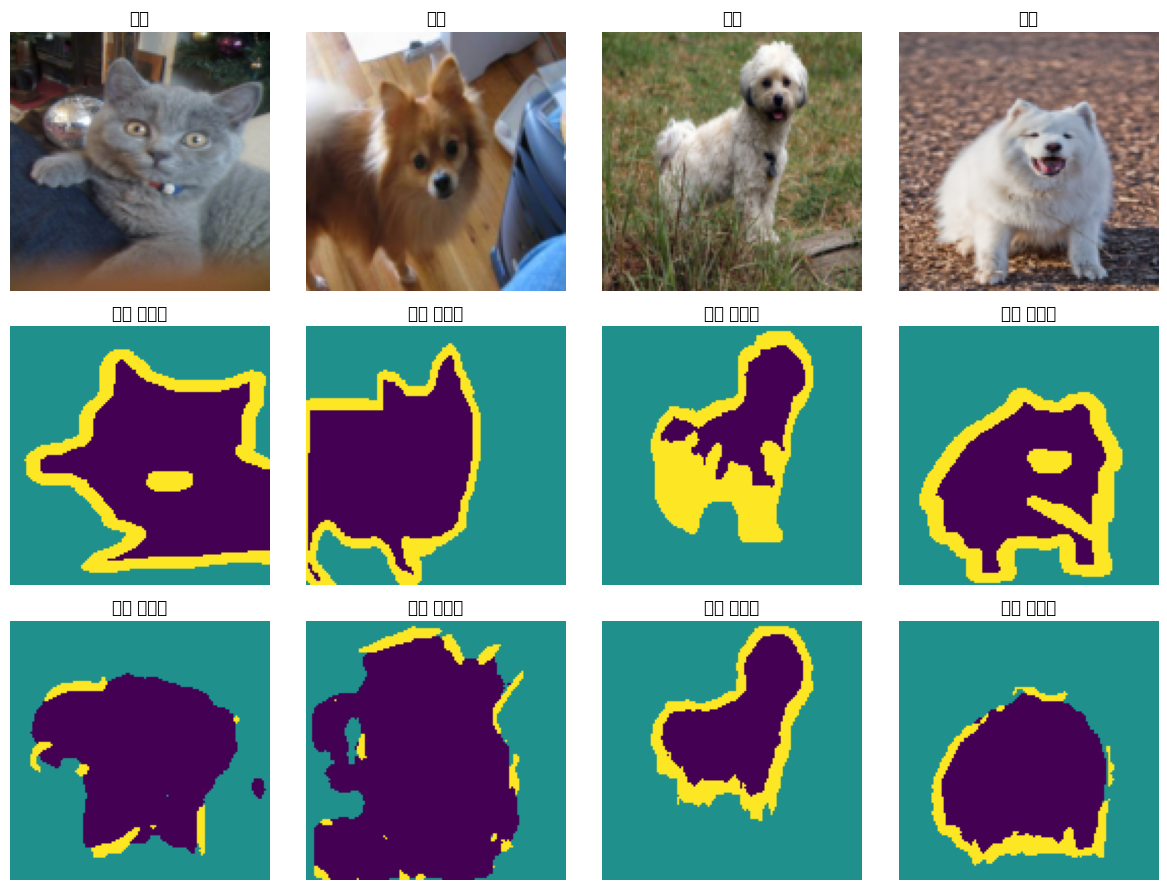

In [5]:
import matplotlib.pyplot as plt

model.eval()
images, masks = next(iter(testloader))
images, masks = images.to(device), masks.to(device)
with torch.no_grad():
    preds = model(images).argmax(dim=1)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for i in range(4):
    img_display = images[i].cpu().permute(1, 2, 0).numpy()
    img_display = (img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]).clip(0, 1)   # 정규화 되돌리기

    axes[0, i].imshow(img_display); axes[0, i].set_title("원본"); axes[0, i].axis('off')
    axes[1, i].imshow(masks[i].cpu(), cmap='viridis'); axes[1, i].set_title("실제 마스크"); axes[1, i].axis('off')
    axes[2, i].imshow(preds[i].cpu(), cmap='viridis'); axes[2, i].set_title("예측 마스크"); axes[2, i].axis('off')
plt.tight_layout()
plt.show()